In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.metrics import mean_absolute_error
from xgboost import XGBRegressor
BASE_DIR = Path("C:/Users/VSB-AIDSPC20/Downloads/demand forecating")
DATA_DIR = BASE_DIR / "data" / "processed"

train = pd.read_csv(DATA_DIR / "train_features.csv", parse_dates=["date"])
valid = pd.read_csv(DATA_DIR / "valid_features.csv", parse_dates=["date"])

train.shape, valid.shape


((716500, 20), (182500, 20))

In [5]:
X_train = train.drop(columns=["sales", "date"])
y_train = train["sales"]

X_valid = valid.drop(columns=["sales", "date"])
y_valid = valid["sales"]



In [6]:
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [7]:
xgb_preds = xgb.predict(X_valid)

# Attach predictions to validation dataframe
valid = valid.copy()
valid["predicted_sales"] = xgb_preds


In [9]:
valid["error"] = valid["sales"] - valid["predicted_sales"]
valid["abs_error"] = valid["error"].abs()

valid[["sales", "predicted_sales", "error"]].head()


,sales,predicted_sales,error
0,19,20.202833,-1.202833
1,15,13.313437,1.686563
2,10,14.722566,-4.722566
3,16,15.071463,0.928537
4,14,15.927969,-1.927969


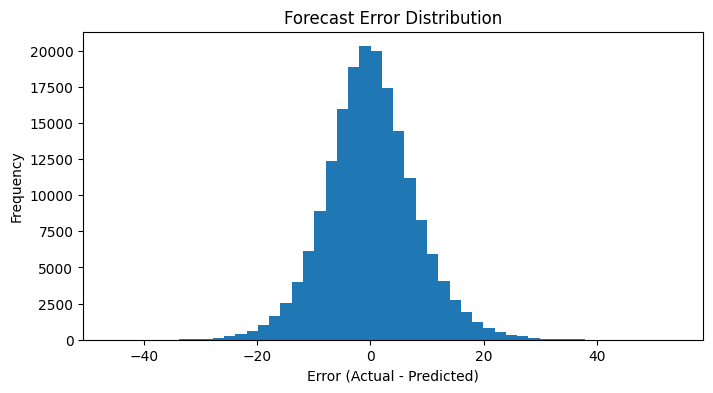

In [10]:
plt.figure(figsize=(8,4))
plt.hist(valid["error"], bins=50)
plt.title("Forecast Error Distribution")
plt.xlabel("Error (Actual - Predicted)")
plt.ylabel("Frequency")
plt.show()


In [11]:
valid["demand_bucket"] = pd.qcut(
    valid["sales"],
    q=4,
    labels=["Low", "Medium", "High", "Very High"]
)

bucket_error = valid.groupby("demand_bucket")["abs_error"].mean()
bucket_error


C:\Users\VSB-AIDSPC20\AppData\Local\Temp\ipykernel_18108\464834654.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket_error = valid.groupby("demand_bucket")["abs_error"].mean()


demand_bucket
Low          4.265085
Medium       5.417223
High         6.471541
Very High    8.422795
Name: abs_error, dtype: float64

In [12]:
worst_items = (
    valid.groupby(["store", "item"])["abs_error"]
         .mean()
         .sort_values(ascending=False)
         .head(10)
)

worst_items


store  item
2      18      10.044250
       28      10.017927
8      15       9.725407
2      15       9.482375
       45       9.458178
       13       9.389121
       25       9.334971
       38       9.307042
8      28       9.296599
       13       9.265640
Name: abs_error, dtype: float64

In [13]:
OUTPUT_PATH = DATA_DIR / "valid_with_predictions.csv"
valid.to_csv(OUTPUT_PATH, index=False)

print("Saved validation data with predictions:", OUTPUT_PATH)


Saved validation data with predictions: C:\Users\VSB-AIDSPC20\Downloads\demand forecating\data\processed\valid_with_predictions.csv
